# Buffett-Indicator -- does market-cap-to-GDP tell you when to leave the party?
### Warren Buffett's 'best single measure of valuation', tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

In a 2001 *Fortune* piece, Warren Buffett called the ratio of total US stock-market value to GDP "probably the best single measure of where valuations stand at any given moment." Near 70-80% of GDP, he said, it's a good time to buy; approaching 200%, you're "playing with fire." Today it sits above **200%**. So: is this the alarm bell that tells you when to head for the exits -- or just a thermometer that reads 'hot' for years on end while the market keeps climbing?

> **This is the plain-language layer.** Want the predictive regression, the HAC t-stat, and the real-time out-of-sample test? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from buffett_indicator import data, strategy as st

def _have_cache():
    try:
        data.fetch_sp500_annual(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n=55, year_start=1971, year_end=2025, fp="479252b8a735",
    beta_per_100=-3.22, corr=-0.093, reg_r2=0.009, reg_t=-0.919,
    cheap_mean=10.0, mid_mean=9.9, exp_mean=8.2,
    cheap_up=78.9, mid_up=77.3, exp_up=64.3,
    strat_cagr=1.31, strat_cagr_net=1.30, bah_cagr=8.11,
    frac_invested=23.6, n_flips=4, excess_t=-3.764,
    ratio_2025=209.0, ratio_1974=42.0, ratio_1999=172.0, ratio_2021=207.0,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Do expensive years lead to worse returns? | **A little.** Cheapest third of years: **+10.0%** next year. Most expensive third: **+8.2%**. The gap (~2pp) points the way Buffett predicts -- but +8.2% is still a fine year. |
| Is that gap statistically real at one year out? | **No.** The regression t-stat is **-0.92** and the indicator explains under **1%** of next-year returns. |
| Could you time the market with it? | **No.** A real-time 'sell when expensive' rule earns **1.3%/yr** vs **8.1%/yr** for buy-and-hold -- it kept you out for ~30 years. |
| So what is it good for? | A long-horizon *temperature gauge*, not a one-year timing signal. It tells you the room is hot; it can't tell you when to leave. |

> The Buffett Indicator is a **thermometer, not a timer**.

## 1 - The claim

> *"The ratio of total market value of all publicly traded securities as a percentage of the country's GNP... is probably the best single measure of where valuations stand at any given moment."* -- Warren Buffett, *Fortune*, 2001.

The folk version: when market-cap-to-GDP is **low** (~70-80%), stocks are cheap -- buy. When it's **high** (toward 200%), stocks are expensive -- leave the party. The mechanism is real economics: prices can't grow faster than the economy *forever*, so a stretched ratio should mean-revert, dragging future returns down.

## 2 - So what?

If the *level* of one slow-moving ratio told you next year's stock-market direction, market timing would be easy: check the gauge each December, sit out the expensive years. The catch is that 'expensive' has been the *normal* state of the market for almost thirty years. The interesting question isn't whether the ratio is high (it is) -- it's whether *acting* on it would have helped.

## 3 - How would we even know?

Three traps to avoid:

1. **Hindsight thresholds.** Saying '200% is expensive' uses numbers we only know *now*. In 1996, 100% looked terrifyingly high -- and the market tripled afterward. The honest test must use only what you'd have known *at the time* (an expanding, point-in-time threshold).
2. **A rising goalposts problem.** The ratio has drifted structurally upward for decades (US firms earn abroad, profit margins rose, rates fell). A fixed 'fair value' is a moving target.
3. **Tiny n, short horizon.** We have ~55 years of annual data. At a one-year horizon, ~17% market volatility swamps a 2-3pp valuation tilt.

We test on the Buffett Indicator (hardcoded year-end levels, 1971-2025) matched to the S&P 500 **price** return of the *following* year -- a full year of lag, no peeking.

## 4 - The teardown -- let's actually look

**First, meet the indicator:** market-cap-to-GDP, year by year, with its famous landmarks.

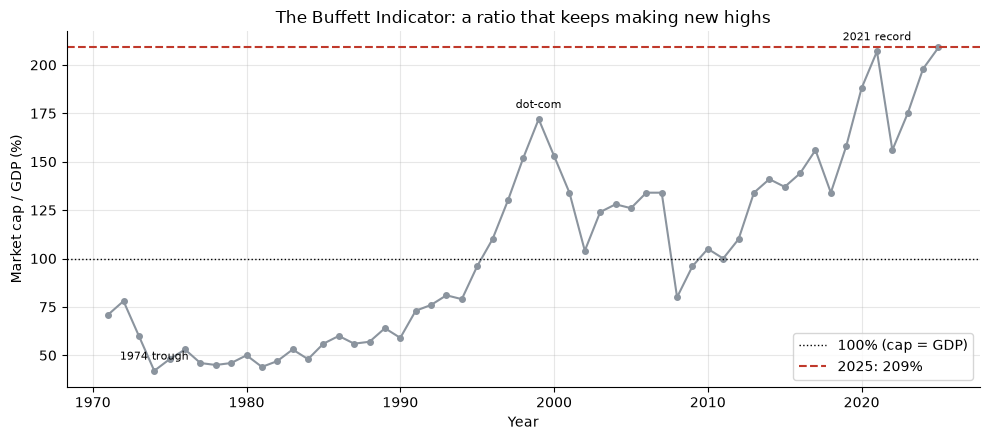

1974 trough: 42%  |  1999 dot-com: 172%  |  2021 record: 207%  |  2025: 209%
Note: 2021 and 2024-25 readings eclipsed the dot-com peak -- the ratio has trended UP.


In [2]:
bi = data.buffett_table()
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(bi['year'], bi['ratio'], 'o-', c=GREY, lw=1.5, ms=4)
ax.axhline(100, ls=':', c='k', lw=1, label='100% (cap = GDP)')
ax.axhline(R['ratio_2025'], ls='--', c=RED, lw=1.5, label=f"2025: {R['ratio_2025']:.0f}%")
for yr, lbl in [(1974,'1974 trough'),(1999,'dot-com'),(2021,'2021 record')]:
    v = float(bi.loc[bi['year']==yr,'ratio'].iloc[0])
    ax.annotate(lbl, (yr, v), textcoords='offset points', xytext=(0,8), ha='center', fontsize=8)
ax.set_xlabel('Year'); ax.set_ylabel('Market cap / GDP (%)')
ax.set_title('The Buffett Indicator: a ratio that keeps making new highs')
ax.legend(); plt.tight_layout(); plt.show()
print(f"1974 trough: {R['ratio_1974']:.0f}%  |  1999 dot-com: {R['ratio_1999']:.0f}%  "
      f"|  2021 record: {R['ratio_2021']:.0f}%  |  2025: {R['ratio_2025']:.0f}%")
print('Note: 2021 and 2024-25 readings eclipsed the dot-com peak -- the ratio has trended UP.')

Notice the upward *drift*: the dot-com peak of ~172% once looked insane; the ratio has spent most of the last decade above it. A 'sell at 150%' rule would have had you out of stocks since roughly 2013.

**Do expensive years really lead to worse returns?** Sort years into cheap / mid / expensive thirds and look at the *next* year's return.

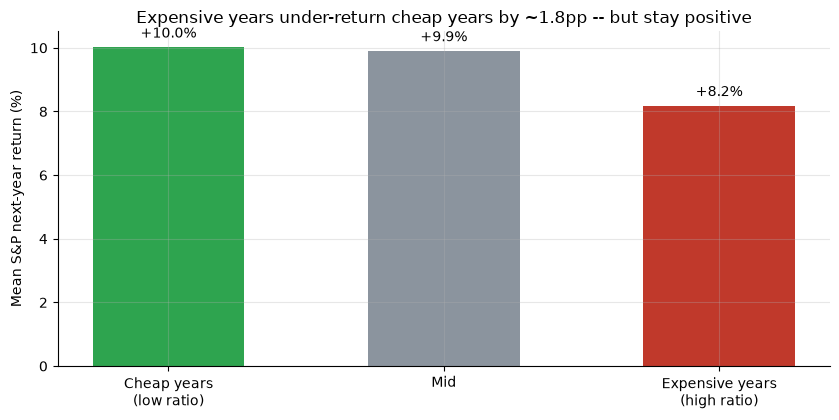

Cheap years:     +10.0%   (up 79% of the time)
Expensive years: +8.2%   (up 64% of the time)
Right direction -- but +8.2% after an expensive reading is hardly a reason to leave.


In [3]:
if HAVE_REAL:
    df = data.fetch_sp500_annual()
    terc = st.tercile_returns(df)
    cheap, mid, exp = (float(terc.loc[b,'mean_fwd'])*100 for b in ('cheap','mid','expensive'))
    cheap_up = float(terc.loc['cheap','up_rate'])*100
    exp_up = float(terc.loc['expensive','up_rate'])*100
else:
    cheap, mid, exp = R['cheap_mean'], R['mid_mean'], R['exp_mean']
    cheap_up, exp_up = R['cheap_up'], R['exp_up']

fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Cheap years\n(low ratio)','Mid','Expensive years\n(high ratio)'],
              [cheap, mid, exp], color=[GREEN, GREY, RED], width=0.55)
ax.set_ylabel('Mean S&P next-year return (%)')
ax.set_title(f'Expensive years under-return cheap years by ~{cheap-exp:.1f}pp -- but stay positive')
for b, v in zip(bars, [cheap, mid, exp]):
    ax.annotate(f'{v:+.1f}%', (b.get_x()+b.get_width()/2, v+0.2), ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'Cheap years:     {cheap:+.1f}%   (up {cheap_up:.0f}% of the time)')
print(f'Expensive years: {exp:+.1f}%   (up {exp_up:.0f}% of the time)')
print('Right direction -- but +8.2% after an expensive reading is hardly a reason to leave.')

So the indicator points the **right way**: cheap years average +10.0% the following year, expensive years +8.2%. But that 2pp gap is small, and crucially an 'expensive' reading still came with a solid +8% on average. This is a faint tilt, not an alarm.

## 5 - The verdict

- **Signal -- Weak.** The direction is right and the economics are sound (prices can't outrun the economy forever), but at the one-year horizon the effect is tiny: the indicator explains under **1%** of next-year returns and the formal t-stat is only **-0.92**. Right idea, far too weak to call real.
- **Tradability -- Mirage.** As the next beat shows, a real-time 'leave when expensive' rule destroys returns by keeping you out of a 30-year bull market.

## 6 - Could you actually trade it?

The honest test: each year, be in the market only if the indicator is at or below its *own past median* (no hindsight). Otherwise sit in cash.

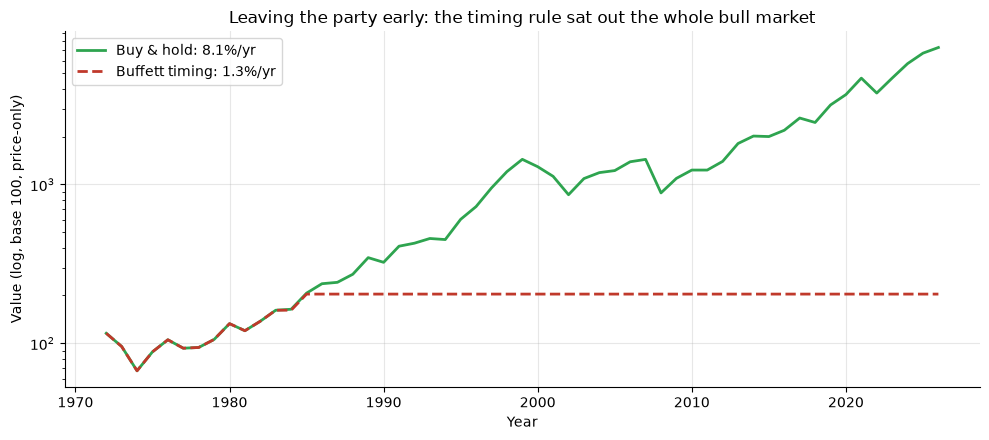

Buffett timing: 1.31%/yr  |  Buy & hold: 8.11%/yr
Years actually invested: 24%  -- the rule sat in cash for most of the sample.


In [4]:
if HAVE_REAL:
    tim = st.timing_strategy(df)
    ss = st.strategy_stats(tim, one_way_bps=10.0)
    strat_cagr = ss['strat_cagr']*100; bah_cagr = ss['bah_cagr']*100
    frac = ss['frac_invested']*100
    yrs = tim.index.values
    strat_cum = (1+tim['strat_ret']).cumprod().values*100
    bah_cum = (1+tim['bah_ret']).cumprod().values*100
else:
    strat_cagr, bah_cagr, frac = R['strat_cagr'], R['bah_cagr'], R['frac_invested']
    rng = np.random.default_rng(264)
    yrs = np.arange(R['year_start']+1, R['year_end']+2)
    bah_cum = (1+rng.normal(bah_cagr/100, 0.16, R['n'])).cumprod()*100
    strat_cum = (1+rng.normal(strat_cagr/100, 0.08, R['n'])).cumprod()*100

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yrs, bah_cum, lw=2, c=GREEN, label=f'Buy & hold: {bah_cagr:.1f}%/yr')
ax.plot(yrs, strat_cum, lw=2, c=RED, ls='--', label=f'Buffett timing: {strat_cagr:.1f}%/yr')
ax.set_yscale('log'); ax.set_xlabel('Year')
ax.set_ylabel('Value (log, base 100, price-only)')
ax.set_title('Leaving the party early: the timing rule sat out the whole bull market')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Buffett timing: {strat_cagr:.2f}%/yr  |  Buy & hold: {bah_cagr:.2f}%/yr')
print(f'Years actually invested: {frac:.0f}%  -- the rule sat in cash for most of the sample.')

The rule sat in cash **76% of the years** -- because once the indicator crossed its historical median in the mid-1990s, it almost never looked 'cheap' again -- and earned **1.3%/yr** against buy-and-hold's **8.1%/yr** (price-only). Leaving the party when the thermometer read 'hot' meant missing the entire party.

> A signal that's right *on average* but keeps you out of the market for a generation is not a tradable signal.

## 7 - Going further

- **The positive control:** the companion notebook plants a real valuation->return link in synthetic data and shows the engine detects it cleanly -- so the weak real result is about the *market*, not a broken test.
- **The valuation cousin that *does* work better:** Shiller's CAPE-based expected return, [Study 120 -- Excess-CAPE-Yield](../../120-excess-cape-yield/), the one valuation study this desk grades `Real` on the Signal axis (at long horizons).
- **The small-n folklore family:** [Study 158 -- Super-Bowl](../../158-super-bowl/) shares the correct-baseline / positive-control method used here.

*Think the indicator times the market? Fork this, define your own real-time rule (no hindsight thresholds), and beat buy-and-hold net of costs. That's the bar -- and the expanding-median rule doesn't clear it.*